# Discovery of Meteorological Patterns Associated with High PM2.5 Pollution Episodes in Kathmandu

This notebook looks at how Kathmandu's weather conditions relate to periods of high PM2.5. The data contain 7,637 hourly observations from 2019. We used exploratory plots, K-Means clustering, association rules and classification models to examine the question from different angles.


In [1]:
from pathlib import Path
import sys
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

warnings.filterwarnings('ignore', category=FutureWarning)
sns.set_theme(style='whitegrid', context='notebook')
pd.set_option('display.max_colwidth', 120)

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
sys.path.insert(0, str(PROJECT_ROOT))

from src.preprocessing import load_and_clean_data, categorize_pm25
from src.clustering import DEFAULT_FEATURES, evaluate_kmeans, fit_kmeans, cluster_profile
from src.association_rules import BIN_FEATURES, build_transactions, mine_high_pm25_rules
from src import classification as clf


## 1. Load, inspect, and clean the data

The dataset was checked for invalid dates, duplicate records and missing values before analysis. Hour and month were taken from the timestamp, and the months were grouped into Kathmandu's four broad seasons.


In [2]:
DATA_PATH = PROJECT_ROOT / 'cleaned_dataset.csv'
df, cleaning_report = load_and_clean_data(DATA_PATH)
print('Shape:', df.shape)
print('Time coverage:', df['date_and_time'].min(), 'to', df['date_and_time'].max())
display(pd.Series(cleaning_report).to_frame('value'))
display(df.head())

Shape: (7637, 18)
Time coverage: 2019-01-01 00:00:00 to 2019-12-31 23:00:00


,value
rows_loaded,7637
duplicate_rows,0
missing_before,"{'date_and_time': 0, 'pm25': 0, 'o3': 0, 'temperature': 0, 'relative_humidity': 0, 'dew_point': 0, 'precipitation': ..."
invalid_dates_removed,0
rows_after_cleaning,7637
missing_after,"{'date_and_time': 0, 'pm25': 0, 'o3': 0, 'temperature': 0, 'relative_humidity': 0, 'dew_point': 0, 'precipitation': ..."


,date_and_time,pm25,o3,temperature,relative_humidity,dew_point,precipitation,rain,pressure_msl,surface_pressure,cloud_cover,vapour_pressure_deficit,wind_speed,wind_direction,wind_gusts,hour,month,season
0,2019-01-01 00:00:00,98,0.000,4.0,71,-0.7,0.0,0.0,1019.6,866.1,0,0.23,6.7,164,11.2,0,1,Winter
1,2019-01-01 01:00:00,114,0.000,5.4,65,-0.7,0.0,0.0,1020.5,867.5,0,0.32,3.8,163,14.8,1,1,Winter
2,2019-01-01 02:00:00,136,0.001,6.4,64,0.0,0.0,0.0,1021.4,868.8,0,0.35,4.5,166,14.0,2,1,Winter
3,2019-01-01 03:00:00,177,0.004,10.0,58,2.2,0.0,0.0,1022.2,871.2,0,0.51,5.7,162,16.6,3,1,Winter
4,2019-01-01 04:00:00,195,0.019,12.9,40,-0.4,0.0,0.0,1022.4,872.8,0,0.90,2.6,106,15.5,4,1,Winter


In [3]:
display(df.dtypes.to_frame('dtype'))
display(df.describe(include='all').T)
print('Remaining duplicate rows:', df.duplicated().sum())
print('Remaining missing values:', int(df.isna().sum().sum()))
display(df.groupby('season', observed=True)['pm25'].agg(['count', 'mean', 'median', 'max']).round(2))

,dtype
date_and_time,datetime64[ns]
pm25,int64
o3,float64
temperature,float64
relative_humidity,int64
dew_point,float64
precipitation,float64
rain,float64
pressure_msl,float64
surface_pressure,float64


,count,unique,top,freq,mean,min,25%,50%,75%,max,std
date_and_time,7637,NaN,NaN,NaN,2019-06-30 06:07:55.631792384,2019-01-01 00:00:00,2019-04-02 10:00:00,2019-06-26 16:00:00,2019-09-27 04:00:00,2019-12-31 23:00:00,NaN
pm25,7637.0,NaN,NaN,NaN,46.09873,1.0,19.0,37.0,61.0,985.0,45.102525
o3,7637.0,NaN,NaN,NaN,0.02896,0.0,0.012,0.025,0.042,0.118,0.021166
temperature,7637.0,NaN,NaN,NaN,17.341011,2.4,13.4,18.4,21.4,29.0,5.574718
relative_humidity,7637.0,NaN,NaN,NaN,78.885033,24.0,69.0,82.0,93.0,100.0,15.927173
dew_point,7637.0,NaN,NaN,NaN,13.298822,-8.6,7.8,14.2,19.1,23.9,6.173613
precipitation,7637.0,NaN,NaN,NaN,0.383567,0.0,0.0,0.0,0.1,30.3,1.453118
rain,7637.0,NaN,NaN,NaN,0.383567,0.0,0.0,0.0,0.1,30.3,1.453118
pressure_msl,7637.0,NaN,NaN,NaN,1011.629514,997.2,1007.0,1012.4,1016.3,1024.7,5.699624
surface_pressure,7637.0,NaN,NaN,NaN,865.589983,855.3,863.2,865.7,868.1,876.4,3.501159


Remaining duplicate rows: 0
Remaining missing values: 0


,count,mean,median,max
season,,,,
Monsoon,2593,17.76,15.0,835
Post-monsoon,1223,43.45,38.0,985
Pre-monsoon,1954,59.43,51.0,985
Winter,1867,73.24,63.0,985


## 2. Exploratory data analysis

We first examined the distribution of PM2.5 and how it changed by month, season and basic weather conditions. This provided useful context before applying the mining methods.

The seasonal difference is clear: winter has the highest mean PM2.5 (73.24), followed by pre-monsoon (59.43). The monsoon mean is much lower at 17.76. Wet hours also have a lower mean than dry hours (28.29 compared with 54.50), which is consistent with rainfall removing particles from the air.


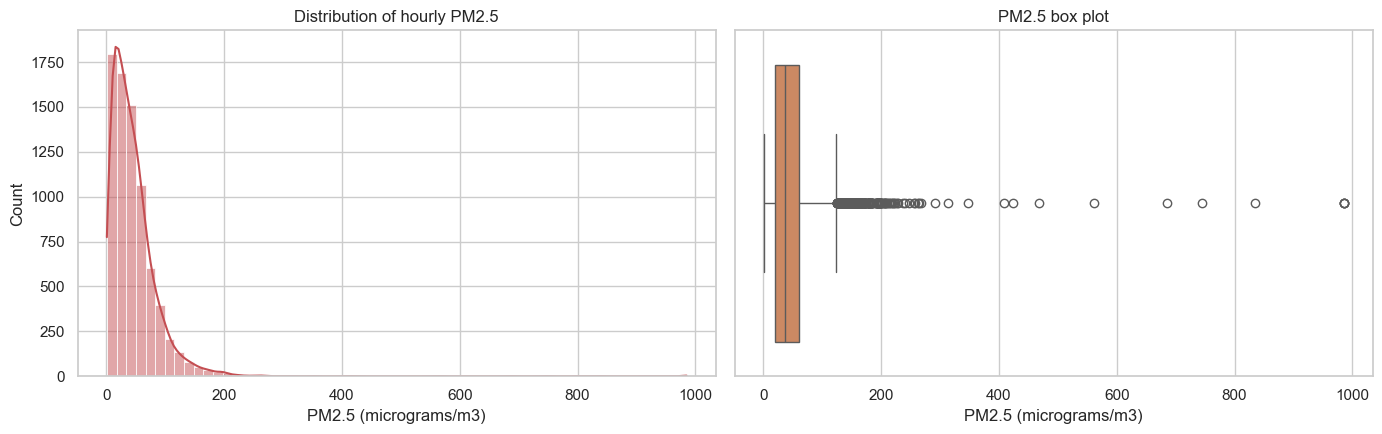

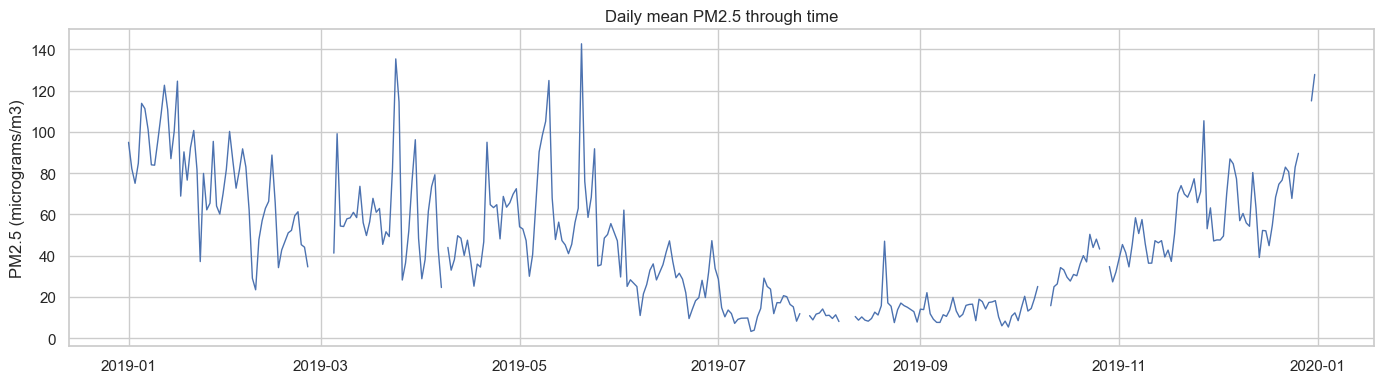

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
sns.histplot(df['pm25'], bins=60, kde=True, ax=axes[0], color='#C44E52')
axes[0].set(title='Distribution of hourly PM2.5', xlabel='PM2.5 (micrograms/m3)')
sns.boxplot(x=df['pm25'], ax=axes[1], color='#DD8452')
axes[1].set(title='PM2.5 box plot', xlabel='PM2.5 (micrograms/m3)')
plt.tight_layout(); plt.show()

daily_pm25 = df.set_index('date_and_time')['pm25'].resample('D').mean()
plt.figure(figsize=(14, 4))
plt.plot(daily_pm25.index, daily_pm25, linewidth=1, color='#4C72B0')
plt.title('Daily mean PM2.5 through time'); plt.ylabel('PM2.5 (micrograms/m3)')
plt.tight_layout(); plt.show()

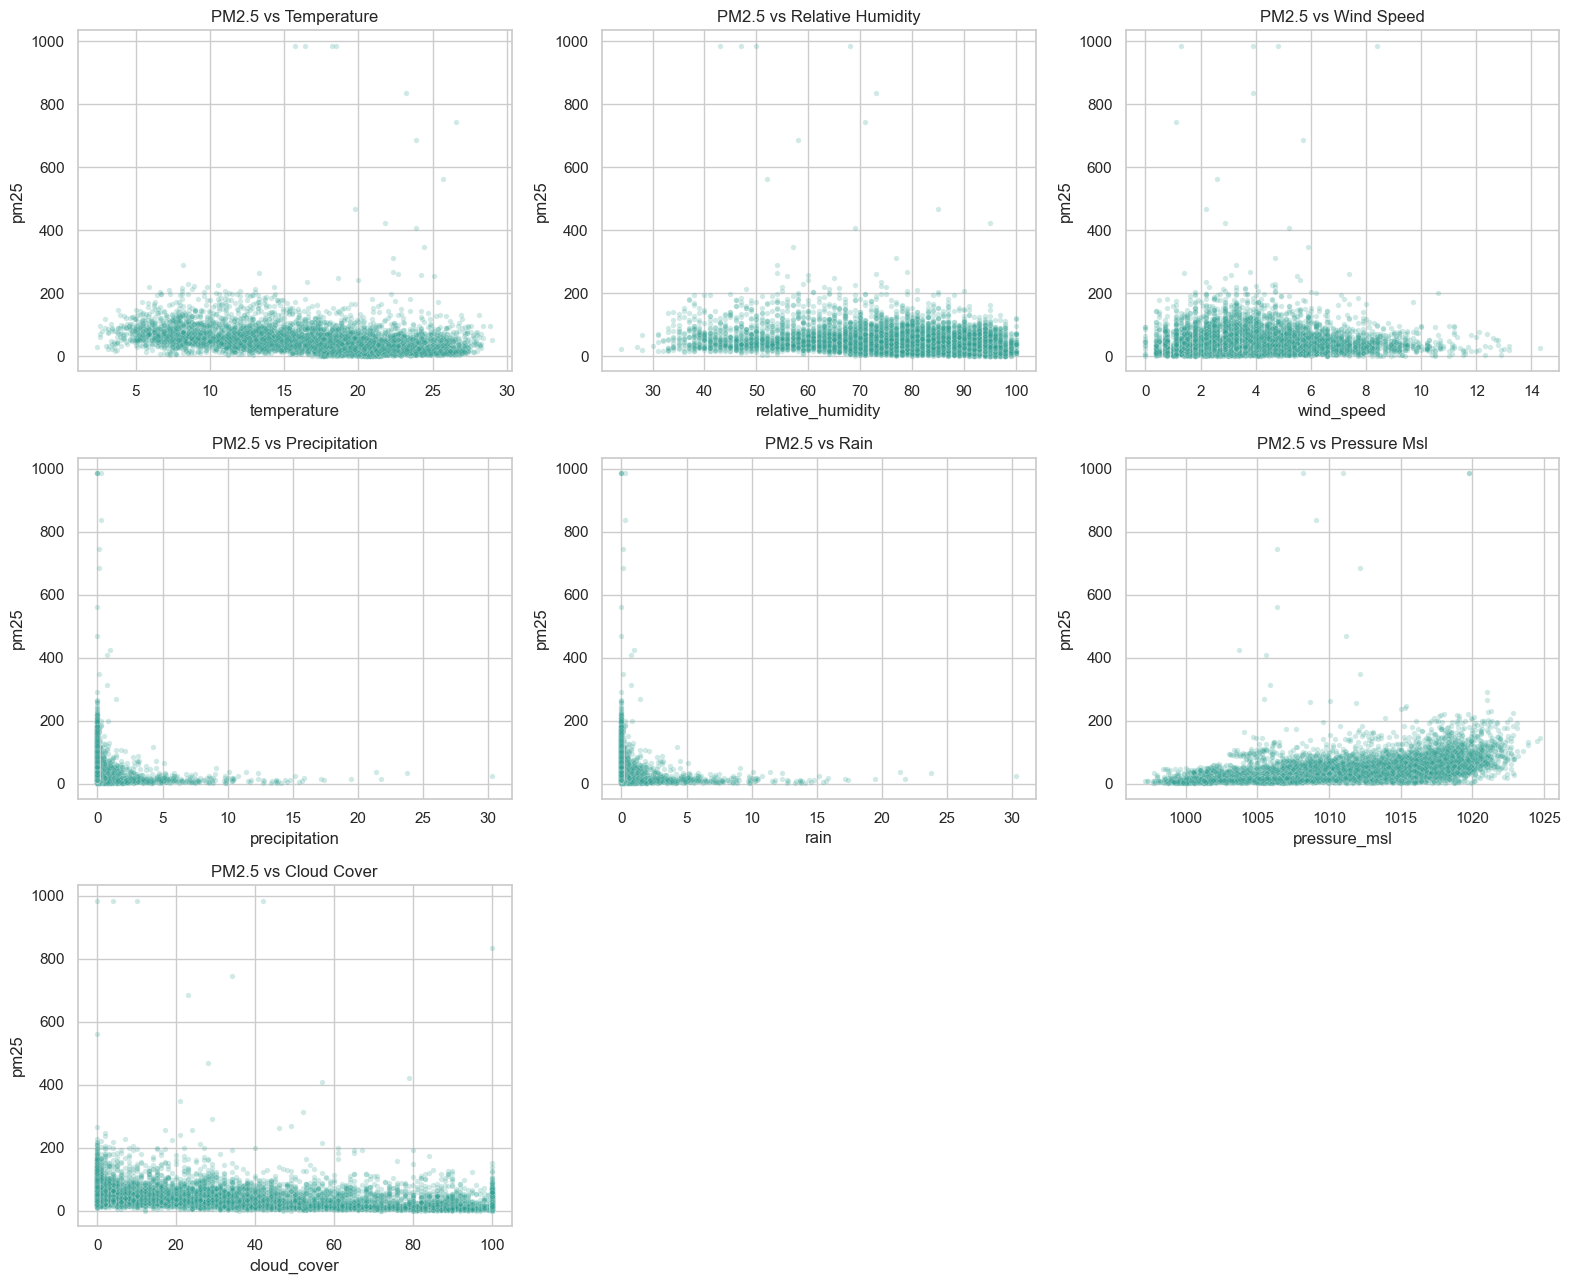

,count,mean,median
rain_state,,,
Dry,5190,54.50,47.0
Wet,2447,28.29,18.0


In [5]:
scatter_features = ['temperature', 'relative_humidity', 'wind_speed', 'precipitation', 'rain', 'pressure_msl', 'cloud_cover']
fig, axes = plt.subplots(3, 3, figsize=(16, 13))
for ax, feature in zip(axes.flat, scatter_features):
    sns.scatterplot(data=df, x=feature, y='pm25', alpha=0.22, s=15, ax=ax, color='#2A9D8F')
    ax.set_title('PM2.5 vs ' + feature.replace('_', ' ').title())
for ax in axes.flat[len(scatter_features):]:
    ax.set_visible(False)
plt.tight_layout(); plt.show()

wet = (df['precipitation'] > 0) | (df['rain'] > 0)
rain_comparison = df.assign(rain_state=np.where(wet, 'Wet', 'Dry')).groupby('rain_state')['pm25'].agg(['count', 'mean', 'median']).round(2)
display(rain_comparison)

### Correlation heatmap

The correlations are descriptive and should not be read as causal effects. PM2.5 has its strongest negative correlation with dew point (-0.467), followed by temperature and cloud cover (both -0.356). Pressure at mean sea level has the strongest positive correlation (0.392). These values suggest that cooler, drier and higher-pressure periods deserve closer attention.


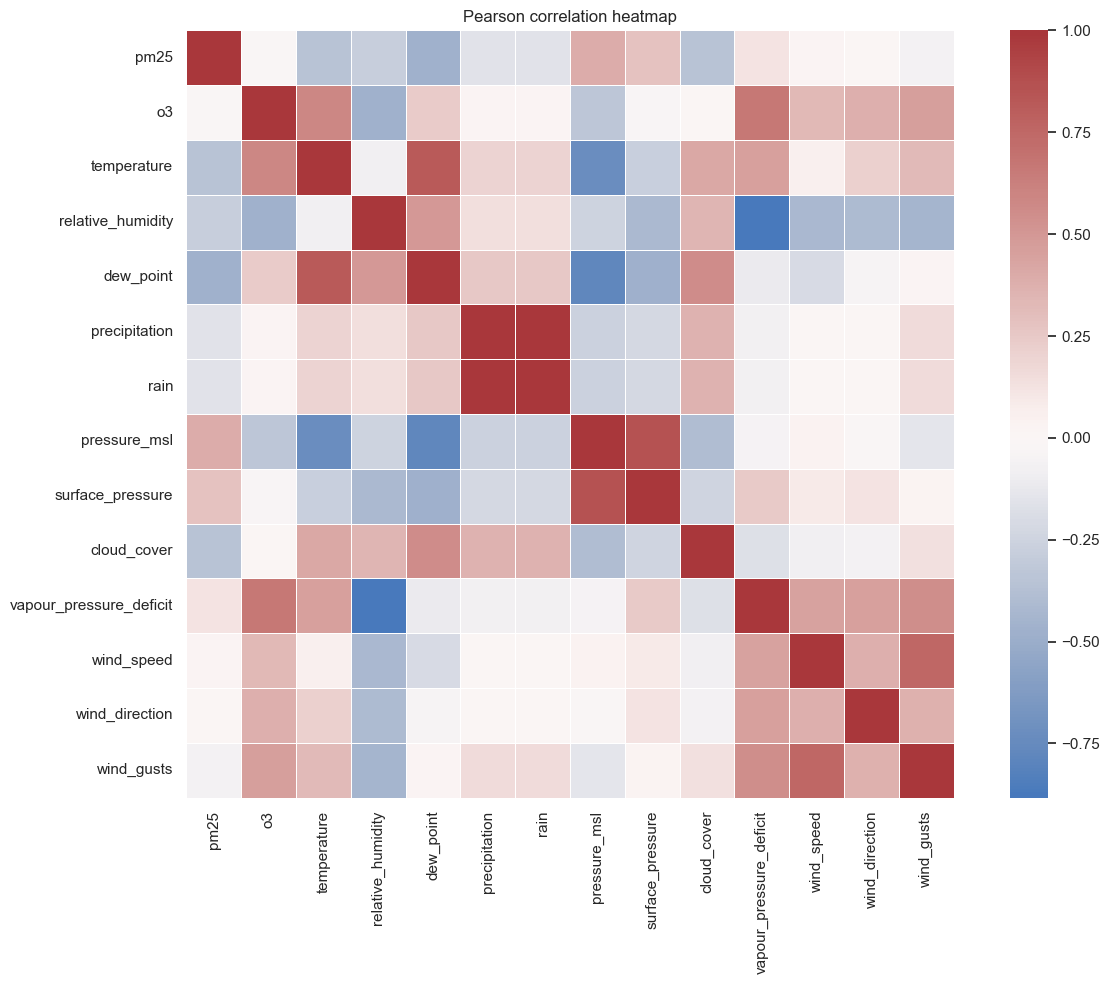

,correlation_with_pm25
dew_point,-0.467
temperature,-0.356
cloud_cover,-0.356
relative_humidity,-0.284
rain,-0.158
precipitation,-0.158
wind_gusts,-0.061
o3,-0.017
wind_direction,0.007
wind_speed,0.025


In [6]:
corr_columns = ['pm25', 'o3', 'temperature', 'relative_humidity', 'dew_point', 'precipitation', 'rain', 'pressure_msl', 'surface_pressure', 'cloud_cover', 'vapour_pressure_deficit', 'wind_speed', 'wind_direction', 'wind_gusts']
correlations = df[corr_columns].corr()
plt.figure(figsize=(13, 10))
sns.heatmap(correlations, cmap='vlag', center=0, square=True, linewidths=.4)
plt.title('Pearson correlation heatmap'); plt.tight_layout(); plt.show()
display(correlations['pm25'].drop('pm25').sort_values().to_frame('correlation_with_pm25').round(3))

## 3. K-Means clustering of meteorological regimes

K-Means was used to group hours with similar weather rather than to predict PM2.5. The input variables were standardized so that features measured on larger numerical scales did not dominate the distance calculation. Several values of *k* were compared using inertia and the silhouette score.


,k,inertia,silhouette_score
0,2,40877.5478,0.2464
1,3,30304.5737,0.2849
2,4,25408.1037,0.2940
3,5,23032.1304,0.2631
4,6,20818.3357,0.2311
5,7,19073.8617,0.2275
6,8,17580.7459,0.2361


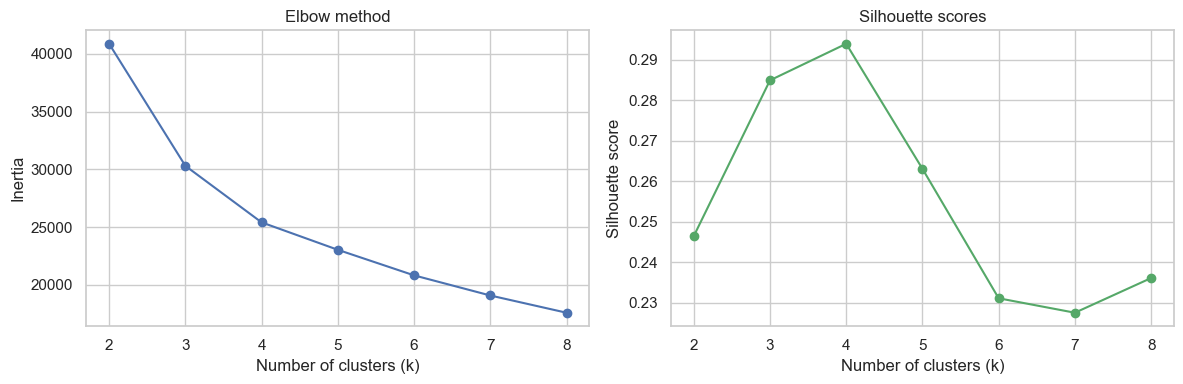

Selected k = 4 (highest tested silhouette score).


In [7]:
diagnostics, _ = evaluate_kmeans(df, DEFAULT_FEATURES)
display(diagnostics.round(4))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(diagnostics['k'], diagnostics['inertia'], marker='o', color='#4C72B0')
axes[0].set(title='Elbow method', xlabel='Number of clusters (k)', ylabel='Inertia')
axes[1].plot(diagnostics['k'], diagnostics['silhouette_score'], marker='o', color='#55A868')
axes[1].set(title='Silhouette scores', xlabel='Number of clusters (k)', ylabel='Silhouette score')
plt.tight_layout(); plt.show()

selected_k = int(diagnostics.loc[diagnostics['silhouette_score'].idxmax(), 'k'])
print(f'Selected k = {selected_k} (highest tested silhouette score).')

,n_observations,temperature,relative_humidity,precipitation,pressure_msl,cloud_cover,vapour_pressure_deficit,wind_speed,pm25,share_percent
cluster,,,,,,,,,,
0,2893,11.750000,81.880000,0.040000,1016.010000,19.420000,0.250000,3.420000,63.500000,37.900000
1,1779,20.370000,57.290000,0.090000,1012.240000,27.300000,1.040000,5.730000,54.690000,23.300000
2,2773,20.870000,88.960000,0.410000,1007.180000,63.540000,0.290000,2.950000,24.710000,36.300000
3,192,22.550000,88.270000,7.840000,1004.110000,92.210000,0.340000,4.070000,13.260000,2.500000


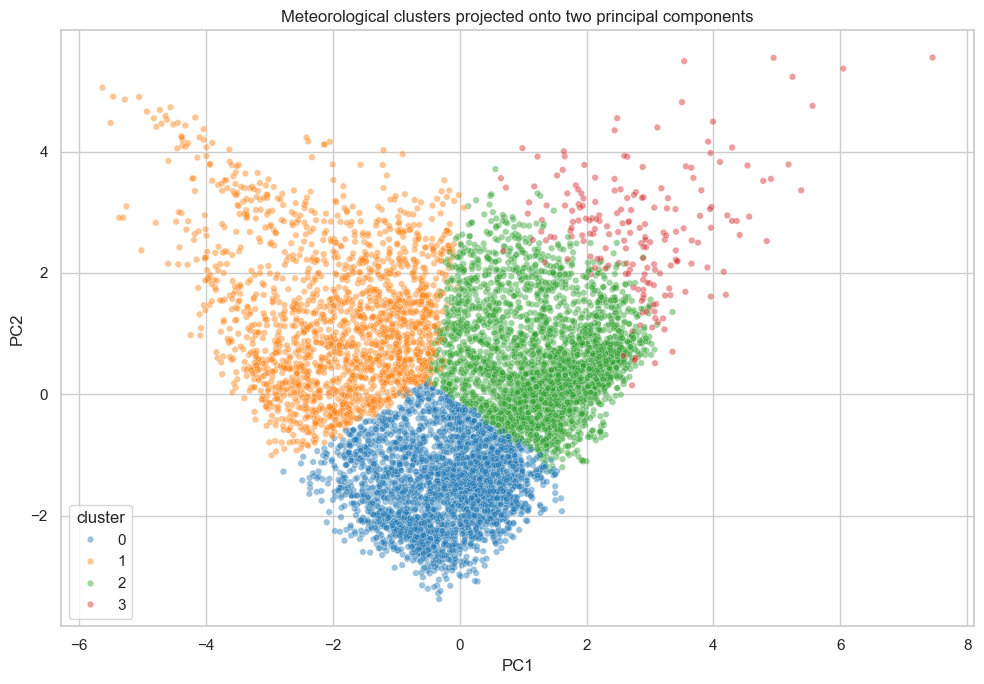

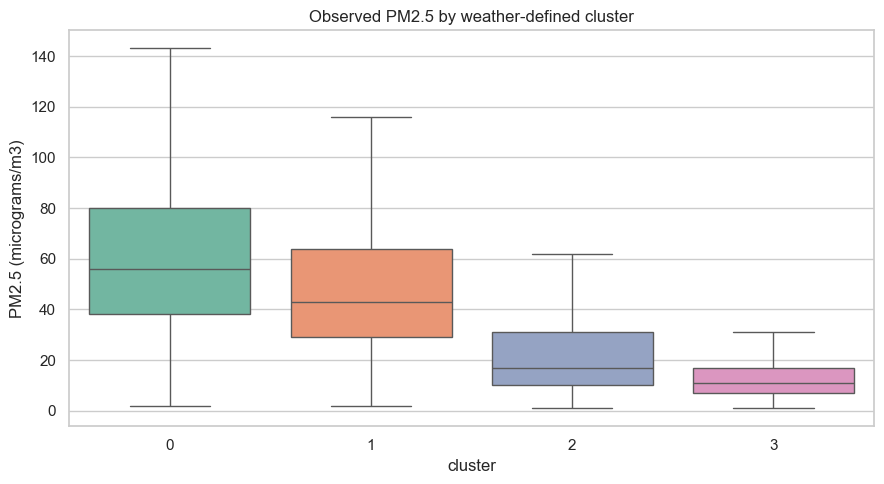

In [8]:
clustered, kmeans_model, scaler, pca = fit_kmeans(df, selected_k, DEFAULT_FEATURES)
profiles = cluster_profile(clustered, DEFAULT_FEATURES)
display(profiles.style.background_gradient(subset=[*DEFAULT_FEATURES, 'pm25'], cmap='YlGnBu'))

plt.figure(figsize=(10, 7))
sns.scatterplot(data=pca, x='PC1', y='PC2', hue='cluster', palette='tab10', alpha=.45, s=22)
plt.title('Meteorological clusters projected onto two principal components')
plt.tight_layout(); plt.show()

plt.figure(figsize=(9, 5))
sns.boxplot(data=clustered, x='cluster', y='pm25', showfliers=False, palette='Set2')
plt.title('Observed PM2.5 by weather-defined cluster')
plt.ylabel('PM2.5 (micrograms/m3)'); plt.tight_layout(); plt.show()

### Data-derived cluster interpretation

Four clusters give the best silhouette score among the tested choices (0.294). The clearest high-pollution cluster contains cooler, more humid, drier, higher-pressure and lower-wind observations; its mean PM2.5 is 63.50 compared with 46.10 overall. The two wetter, lower-pressure clusters have below-average PM2.5 means. The clusters overlap, so they are best viewed as broad weather regimes rather than sharply separated categories.


In [9]:
overall = df[[*DEFAULT_FEATURES, 'pm25']].mean()
for cluster_id, row in profiles.iterrows():
    weather = [f.replace('_', ' ') + (' above average' if row[f] >= overall[f] else ' below average') for f in DEFAULT_FEATURES]
    pm_text = 'above' if row['pm25'] >= overall['pm25'] else 'below'
    print('Cluster {} (n={}): {}. Mean PM2.5 is {} the overall mean ({:.2f} vs {:.2f}).'.format(cluster_id, int(row['n_observations']), ', '.join(weather), pm_text, row['pm25'], overall['pm25']))

Cluster 0 (n=2893): temperature below average, relative humidity above average, precipitation below average, pressure msl above average, cloud cover below average, vapour pressure deficit below average, wind speed below average. Mean PM2.5 is above the overall mean (63.50 vs 46.10).
Cluster 1 (n=1779): temperature above average, relative humidity below average, precipitation below average, pressure msl above average, cloud cover below average, vapour pressure deficit above average, wind speed above average. Mean PM2.5 is above the overall mean (54.69 vs 46.10).
Cluster 2 (n=2773): temperature above average, relative humidity above average, precipitation above average, pressure msl below average, cloud cover above average, vapour pressure deficit below average, wind speed below average. Mean PM2.5 is below the overall mean (24.71 vs 46.10).
Cluster 3 (n=192): temperature above average, relative humidity above average, precipitation above average, pressure msl below average, cloud cover 

## 4. Association-rule mining

For rule mining, continuous weather variables were divided into low, medium and high groups using tertiles. PM2.5 was placed into severity categories, and each hourly record became a transaction. The rules were filtered to retain only those leading to a high-PM2.5 category. Support shows how often a rule occurs in the full dataset, confidence is the proportion of matching weather records that have the stated PM2.5 outcome, and lift compares that confidence with the outcome's usual frequency.


In [10]:
cut_points = pd.DataFrame({
    feature: df[feature].quantile([1/3, 2/3]).values for feature in BIN_FEATURES
}, index=['Low/Medium boundary', 'Medium/High boundary']).T
display(cut_points.round(3))

df['pm25_severity'] = categorize_pm25(df['pm25'])
display(df['pm25_severity'].value_counts(sort=False).to_frame('observations').assign(percent=lambda x: (100*x['observations']/len(df)).round(2)))
encoded, categorical_data = build_transactions(df)
display(categorical_data.head())
print('Transaction matrix shape:', encoded.shape)

,Low/Medium boundary,Medium/High boundary
temperature,15.133,20.60
relative_humidity,74.000,90.00
wind_speed,2.600,4.30
pressure_msl,1008.600,1015.10
cloud_cover,14.000,52.00
vapour_pressure_deficit,0.180,0.54


,observations,percent
pm25_severity,,
Good,754,9.87
Moderate,2907,38.06
USG,1707,22.35
Unhealthy,1984,25.98
Very_Unhealthy,261,3.42
Hazardous,24,0.31


,temperature,relative_humidity,wind_speed,pressure_msl,cloud_cover,vapour_pressure_deficit,rain_state,wind_direction,pm25_severity
0,temperature=Low,relative_humidity=Low,wind_speed=High,pressure_msl=High,cloud_cover=Low,vapour_pressure_deficit=Medium,rain=Dry,wind=S,PM25=Unhealthy
1,temperature=Low,relative_humidity=Low,wind_speed=Medium,pressure_msl=High,cloud_cover=Low,vapour_pressure_deficit=Medium,rain=Dry,wind=S,PM25=Unhealthy
2,temperature=Low,relative_humidity=Low,wind_speed=High,pressure_msl=High,cloud_cover=Low,vapour_pressure_deficit=Medium,rain=Dry,wind=S,PM25=Very_Unhealthy
3,temperature=Low,relative_humidity=Low,wind_speed=High,pressure_msl=High,cloud_cover=Low,vapour_pressure_deficit=Medium,rain=Dry,wind=S,PM25=Very_Unhealthy
4,temperature=Low,relative_humidity=Low,wind_speed=Low,pressure_msl=High,cloud_cover=Low,vapour_pressure_deficit=High,rain=Dry,wind=E,PM25=Very_Unhealthy


Transaction matrix shape: (7637, 30)


In [12]:
frequent_itemsets, high_rules = mine_high_pm25_rules(encoded, min_support=0.02, min_confidence=0.35, min_lift=1.0)
print('Frequent itemsets:', len(frequent_itemsets))
print('High-PM2.5 target rules:', len(high_rules))
rule_columns = ['antecedent_text', 'consequent_text', 'support', 'confidence', 'lift']
if high_rules.empty:
    print('No rules met all thresholds. This is a valid result; lower thresholds only with an explicit sensitivity analysis.')
else:
    display(high_rules[rule_columns].head(25).round(4))

Frequent itemsets: 3753
High-PM2.5 target rules: 208


,antecedent_text,consequent_text,support,confidence,lift
5672,cloud_cover=Medium & temperature=Low & wind_speed=Low,PM25=Unhealthy,0.0206,0.5992,2.3066
5822,pressure_msl=High & relative_humidity=Medium & temperature=Low,PM25=Unhealthy,0.0541,0.5925,2.2809
5879,pressure_msl=High & temperature=Low & wind_speed=Low,PM25=Unhealthy,0.0390,0.5889,2.2670
5856,pressure_msl=High & temperature=Low & vapour_pressure_deficit=Medium,PM25=Unhealthy,0.0622,0.5814,2.2380
5865,pressure_msl=High & temperature=Low & wind=S,PM25=Unhealthy,0.1053,0.5772,2.2217
5378,cloud_cover=Low & pressure_msl=High & relative_humidity=Medium,PM25=Unhealthy,0.0368,0.5735,2.2075
6230,relative_humidity=Low & vapour_pressure_deficit=Medium & wind=S,PM25=Unhealthy,0.0308,0.5732,2.2063
5809,pressure_msl=High & relative_humidity=Low & wind=S,PM25=Unhealthy,0.0310,0.5670,2.1825
5839,pressure_msl=High & relative_humidity=Medium & wind=S,PM25=Unhealthy,0.0517,0.5627,2.1659
5507,cloud_cover=Low & relative_humidity=Low & vapour_pressure_deficit=Medium,PM25=Unhealthy,0.0261,0.5621,2.1639


### Strongest-rule visualizations

The strongest rules repeatedly include low temperature, high pressure, low wind speed and southerly wind. For example, medium cloud cover combined with low temperature and low wind has a confidence of 0.599 and lift of 2.31 for the Unhealthy category. Its support is only 0.021, however, so the pattern is strong but applies to a small share of all hours.


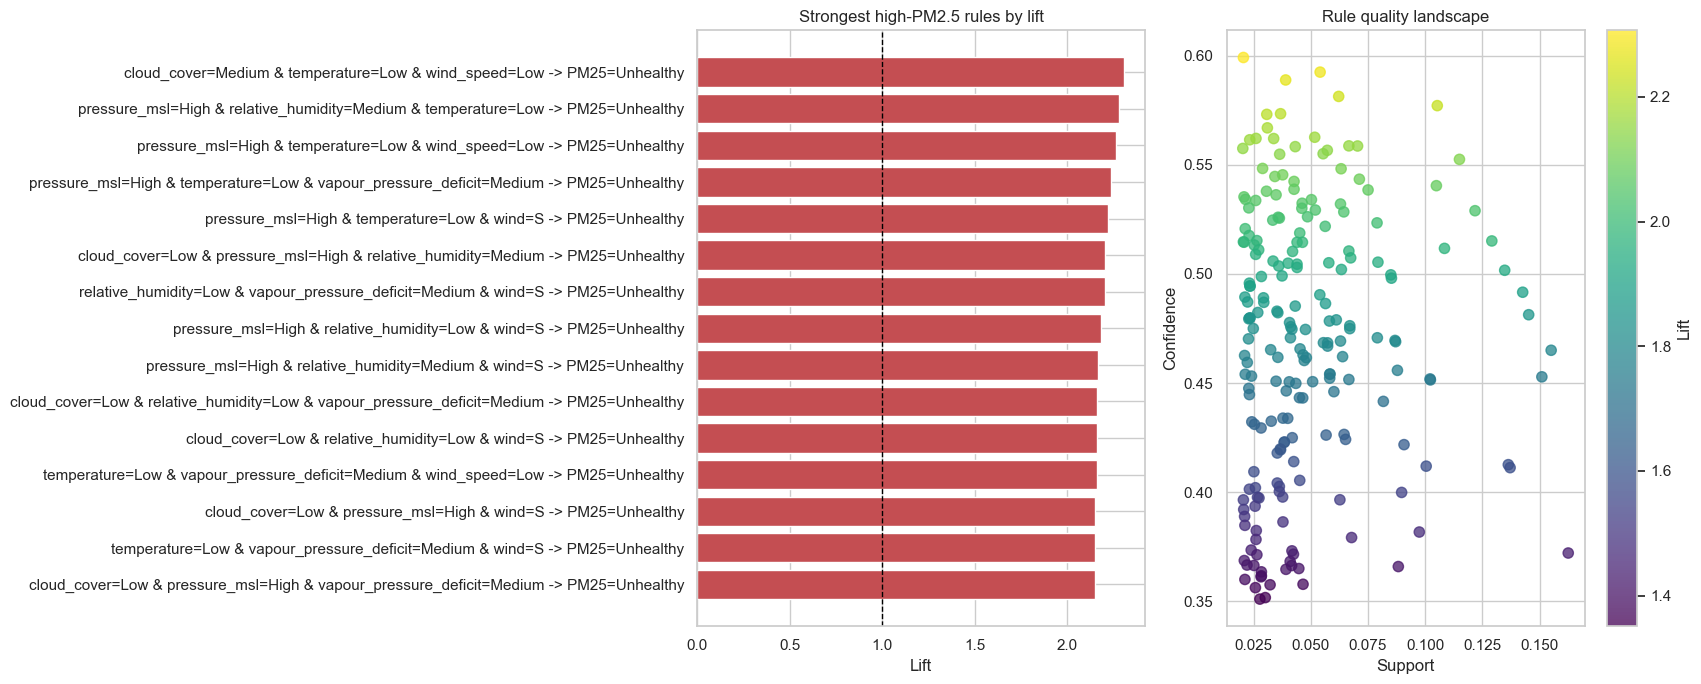

In [13]:
if not high_rules.empty:
    top_rules = high_rules.head(15).copy().sort_values('lift')
    labels = top_rules['antecedent_text'] + ' -> ' + top_rules['consequent_text']
    fig, axes = plt.subplots(1, 2, figsize=(17, 7))
    axes[0].barh(labels, top_rules['lift'], color='#C44E52')
    axes[0].axvline(1, color='black', linestyle='--', linewidth=1)
    axes[0].set(title='Strongest high-PM2.5 rules by lift', xlabel='Lift')
    scatter = axes[1].scatter(high_rules['support'], high_rules['confidence'], c=high_rules['lift'], cmap='viridis', alpha=.75, s=55)
    axes[1].set(title='Rule quality landscape', xlabel='Support', ylabel='Confidence')
    fig.colorbar(scatter, ax=axes[1], label='Lift')
    plt.tight_layout(); plt.show()

## 5. Supervised classification of high-PM2.5 episodes

In this section, we tested how well weather variables identified hours with PM2.5 at or above 55.5. About 29.7% of the observations met this definition. Because the classes were uneven, we reported F1 and ROC-AUC alongside accuracy.


In [14]:
y = clf.make_labels(df)
base_rate = y.mean()
print(f'Rows: {len(df)}')
print(f'High-PM2.5 (>= {clf.HIGH_PM25_THRESHOLD}) base rate: {base_rate:.3f}')
print(f'Majority-class ("never high") baseline accuracy: {1 - base_rate:.3f}')
print('Features used:', ', '.join(clf.CLASSIFIER_FEATURES))

Rows: 7637
High-PM2.5 (>= 55.5) base rate: 0.297
Majority-class ("never high") baseline accuracy: 0.703
Features used: temperature, relative_humidity, dew_point, precipitation, pressure_msl, cloud_cover, vapour_pressure_deficit, wind_speed, wind_direction, wind_gusts


### 5.1 Why the validation protocol decides the story

We first used a random split, which mixed observations from different parts of the year and produced optimistic results. The Random Forest reached an AUC of 0.909 under this split. When we held out the final part of the year instead, every model performed noticeably worse; the best AUC was 0.711. This gap indicates that nearby and seasonally similar observations can leak useful time information into a random test set.


Random 80/20 split (temporally leaky):


,model,accuracy,precision,recall,f1,roc_auc
0,Random Forest,0.834,0.771,0.630,0.693,0.909
1,Decision Tree,0.783,0.601,0.804,0.688,0.862
2,k-NN (k=15),0.812,0.731,0.581,0.648,0.883
3,Logistic Regression,0.736,0.538,0.786,0.639,0.853
4,Naive Bayes,0.707,0.504,0.813,0.622,0.835



Chronological split (honest for time series):


,model,accuracy,precision,recall,f1,roc_auc
0,Logistic Regression,0.511,0.463,0.919,0.616,0.692
1,Naive Bayes,0.496,0.456,0.933,0.612,0.684
2,Decision Tree,0.484,0.451,0.949,0.611,0.702
3,k-NN (k=15),0.668,0.612,0.609,0.610,0.711
4,Random Forest,0.662,0.609,0.583,0.596,0.702


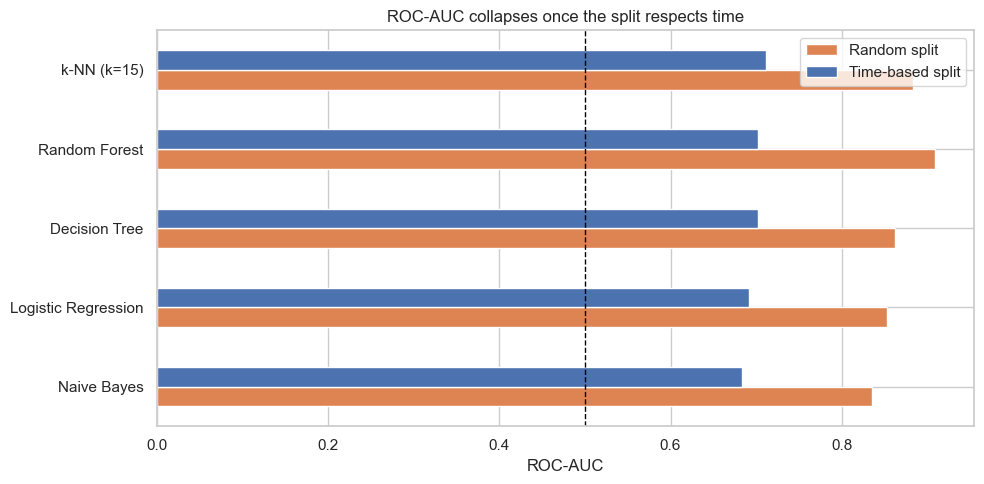

In [15]:
random_scores = clf.naive_random_holdout(df)
time_scores, fitted_models, (X_test, y_test) = clf.evaluate_holdout(df)

print('Random 80/20 split (temporally leaky):')
display(random_scores.round(3))
print('\nChronological split (honest for time series):')
display(time_scores.round(3))

merged = (random_scores[['model', 'roc_auc']].rename(columns={'roc_auc': 'Random split'})
          .merge(time_scores[['model', 'roc_auc']].rename(columns={'roc_auc': 'Time-based split'}),
                 on='model'))
merged_plot = merged.set_index('model').sort_values('Time-based split')
ax = merged_plot.plot(kind='barh', figsize=(10, 5), color=['#DD8452', '#4C72B0'])
ax.axvline(0.5, color='black', linestyle='--', linewidth=1, label='random guessing')
ax.set(title='ROC-AUC collapses once the split respects time', xlabel='ROC-AUC', ylabel='')
plt.tight_layout(); plt.show()

### 5.2 Rolling cross-validation: a more robust time-aware estimate

We used rolling validation to keep the training observations earlier than the test observations. Logistic Regression has the highest mean AUC (0.663), but the fold-to-fold variation is large. Model performance therefore depends strongly on the time of year being tested.


,model,cv_auc_mean,cv_auc_std,cv_f1_mean,cv_f1_std
0,Logistic Regression,0.663,0.090,0.246,0.229
1,k-NN (k=15),0.637,0.141,0.280,0.203
2,Naive Bayes,0.604,0.141,0.273,0.224
3,Random Forest,0.587,0.192,0.277,0.210
4,Decision Tree,0.548,0.157,0.313,0.258


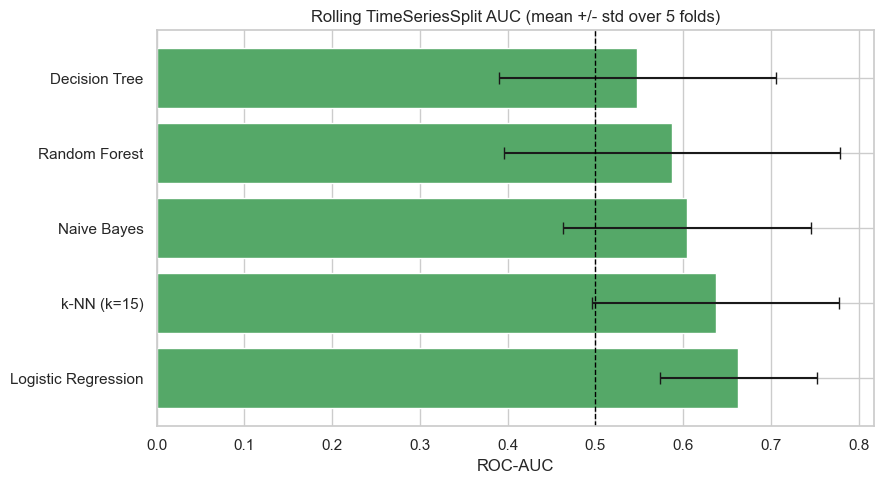

Large standard deviations confirm skill depends heavily on which season
each fold happens to test - a direct symptom of the seasonal signal in 6.5.


In [16]:
cv = clf.rolling_cv_scores(df, n_splits=5)
display(cv.round(3))

fig, ax = plt.subplots(figsize=(9, 5))
ax.barh(cv['model'], cv['cv_auc_mean'], xerr=cv['cv_auc_std'], color='#55A868', capsize=4)
ax.axvline(0.5, color='black', linestyle='--', linewidth=1)
ax.set(title='Rolling TimeSeriesSplit AUC (mean +/- std over 5 folds)', xlabel='ROC-AUC', ylabel='')
plt.tight_layout(); plt.show()

print('Large standard deviations confirm skill depends heavily on which season')
print('each fold happens to test - a direct symptom of the seasonal signal in 6.5.')

### 5.3 Best model on the chronological split: confusion matrix and ROC



Best chronological model by F1: Logistic Regression


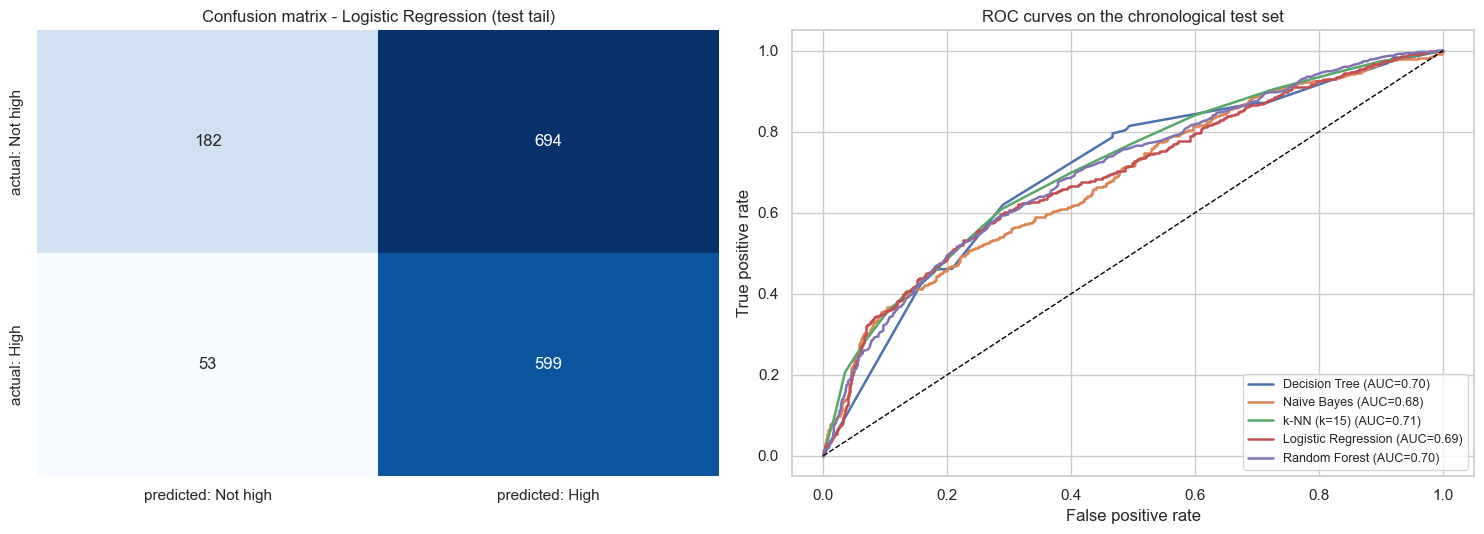

In [17]:
best_name = time_scores.iloc[0]['model']
best_model = fitted_models[best_name]
print(f'Best chronological model by F1: {best_name}')

fig, axes = plt.subplots(1, 2, figsize=(15, 5.5))

cm = clf.confusion_frame(best_model, X_test, y_test)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False, ax=axes[0])
axes[0].set(title=f'Confusion matrix - {best_name} (test tail)')

for name, model in fitted_models.items():
    fpr, tpr, auc = clf.roc_points(model, X_test, y_test)
    axes[1].plot(fpr, tpr, linewidth=1.8, label=f'{name} (AUC={auc:.2f})')
axes[1].plot([0, 1], [0, 1], color='black', linestyle='--', linewidth=1)
axes[1].set(title='ROC curves on the chronological test set',
            xlabel='False positive rate', ylabel='True positive rate')
axes[1].legend(loc='lower right', fontsize=9)
plt.tight_layout(); plt.show()

### 5.4 Interpretability, and does it agree with the association rules?

The Decision Tree places most importance on dew point, with smaller contributions from wind gusts, pressure, cloud cover and relative humidity. This broadly agrees with the unsupervised results: moisture, pressure and air movement repeatedly help distinguish high-pollution conditions. Feature importance does not show the direction of an effect and should not be interpreted as causation.


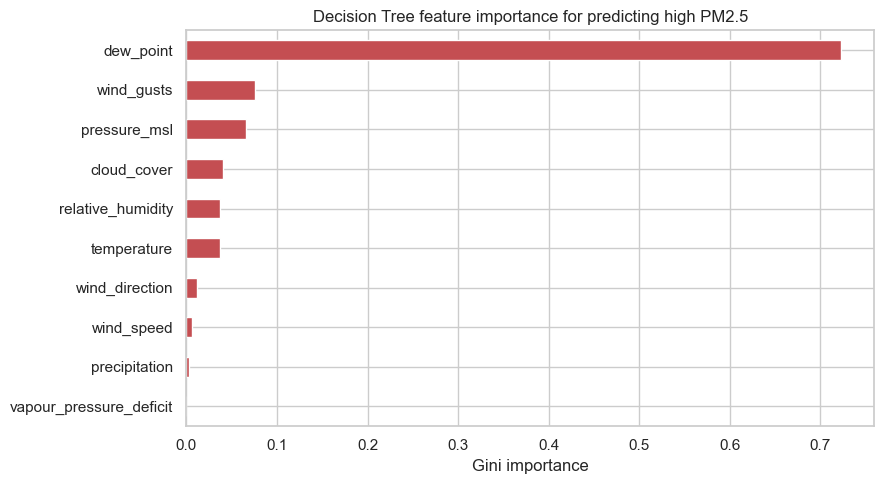

Top drivers:


,importance
dew_point,0.723
wind_gusts,0.075
pressure_msl,0.066
cloud_cover,0.040
relative_humidity,0.037



Readable top splits of the tree:

|--- dew_point <= 17.65
|   |--- dew_point <= 7.35
|   |   |--- wind_gusts <= 21.05
|   |   |   |--- truncated branch of depth 4
|   |   |--- wind_gusts >  21.05
|   |   |   |--- truncated branch of depth 4
|   |--- dew_point >  7.35
|   |   |--- relative_humidity <= 87.50
|   |   |   |--- truncated branch of depth 4
|   |   |--- relative_humidity >  87.50
|   |   |   |--- truncated branch of depth 4
|--- dew_point >  17.65
|   |--- dew_point <= 18.65
|   |   |--- pressure_msl <= 1011.25
|   |   |   |--- truncated branch of depth 4
|   |   |--- pressure_msl >  1011.25
|   |   |   |--- truncated branch of depth 2
|   |--- dew_point >  18.65
|   |   |--- cloud_cover <= 6.50
|   |   |   |--- truncated branch of depth 4
|   |   |--- cloud_cover >  6.50
|   |   |   |--- truncated branch of depth 4



In [17]:
tree = fitted_models['Decision Tree']
importance = clf.tree_feature_importance(tree)

fig, ax = plt.subplots(figsize=(9, 5))
importance.sort_values().plot(kind='barh', color='#C44E52', ax=ax)
ax.set(title='Decision Tree feature importance for predicting high PM2.5', xlabel='Gini importance')
plt.tight_layout(); plt.show()

print('Top drivers:')
display(importance.head(5).round(3).to_frame('importance'))
print('\nReadable top splits of the tree:\n')
print(clf.tree_rules_text(tree, max_depth=2))

### 5.5 How much of this is weather, and how much is just the season?

Weather-only features achieve a mean rolling AUC of 0.593, while month and hour alone reach 0.570. Combining both raises the result only slightly to 0.603. This suggests that much of the apparent weather signal is tied to seasonality, and that weather by itself has limited ability to generalize across the year.


,feature_set,n_features,cv_auc_mean,cv_auc_std
0,weather only,10,0.593,0.183
1,time only (month + hour),2,0.570,0.128
2,weather + time,12,0.603,0.184


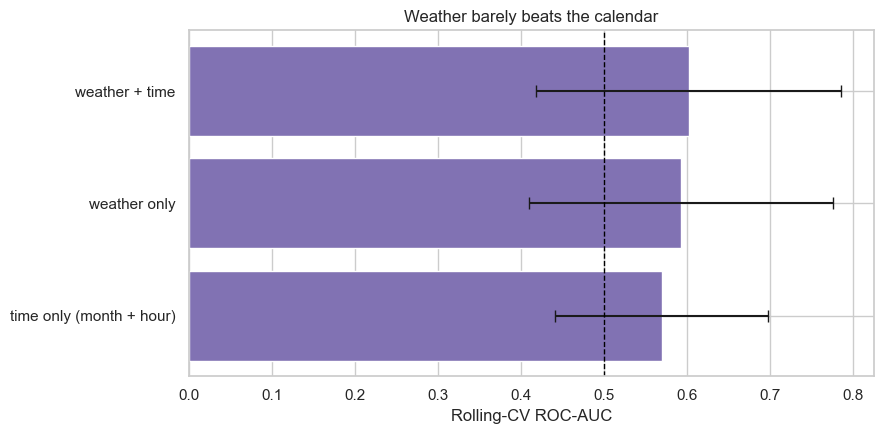

In [18]:
confound = clf.seasonal_confound_auc(df, n_splits=5)
display(confound.round(3))

fig, ax = plt.subplots(figsize=(9, 4.5))
order = confound.sort_values('cv_auc_mean')
ax.barh(order['feature_set'], order['cv_auc_mean'], xerr=order['cv_auc_std'],
        color='#8172B3', capsize=4)
ax.axvline(0.5, color='black', linestyle='--', linewidth=1)
ax.set(title='Weather barely beats the calendar', xlabel='Rolling-CV ROC-AUC', ylabel='')
plt.tight_layout(); plt.show()

## 6. Our Findings


Across the exploratory analysis, clusters and association rules, high PM2.5 is most consistently linked with cool, dry, higher-pressure conditions and weak air movement. Low temperature and high pressure appear in many of the leading rules, while wet monsoon-like conditions generally coincide with lower PM2.5.

These findings should be kept within the scope of the data. The observations cover one year, the rules depend on chosen bins and thresholds, and repeated hourly measurements are not independent. Important influences such as traffic, fuel use, fires and boundary-layer height are also absent. The results describe useful patterns in the supplied 2019 data.


In [20]:
if high_rules.empty:
    print('Under the prespecified thresholds, the dataset does not support a reported meteorological combination associated with high PM2.5.')
else:
    print('Strongest observed combinations associated with high PM2.5:')
    for _, rule in high_rules.head(10).iterrows():
        print('- {} -> {}: support={:.3f}, confidence={:.3f}, lift={:.2f}'.format(rule['antecedent_text'], rule['consequent_text'], rule['support'], rule['confidence'], rule['lift']))


Strongest observed combinations associated with high PM2.5:
- cloud_cover=Medium & temperature=Low & wind_speed=Low -> PM25=Unhealthy: support=0.021, confidence=0.599, lift=2.31
- pressure_msl=High & relative_humidity=Medium & temperature=Low -> PM25=Unhealthy: support=0.054, confidence=0.593, lift=2.28
- pressure_msl=High & temperature=Low & wind_speed=Low -> PM25=Unhealthy: support=0.039, confidence=0.589, lift=2.27
- pressure_msl=High & temperature=Low & vapour_pressure_deficit=Medium -> PM25=Unhealthy: support=0.062, confidence=0.581, lift=2.24
- pressure_msl=High & temperature=Low & wind=S -> PM25=Unhealthy: support=0.105, confidence=0.577, lift=2.22
- cloud_cover=Low & pressure_msl=High & relative_humidity=Medium -> PM25=Unhealthy: support=0.037, confidence=0.573, lift=2.21
- relative_humidity=Low & vapour_pressure_deficit=Medium & wind=S -> PM25=Unhealthy: support=0.031, confidence=0.573, lift=2.21
- pressure_msl=High & relative_humidity=Low & wind=S -> PM25=Unhealthy: support=0